### Hasbrouck VECM Model Fitting
This file calls the classes and functions declared in vecm_hasbrouck2.py to fit the Hasbrouck VECM 

The convention used in this file is:
<ul>
    <li>'um': linear perp</li>
    <li>'cm': inverse perp</li>
</ul>

In [72]:
from vecm_hasbrouck3 import *

### BTC

Fitting the Hasbrouck model

In [ ]:
hasbrouck = VECMHasbrouck2('BTCUSDT', 'Binance', 'um')
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2021, 8, 24)

# differente aggregation levels used
aggs = ['1s', '500ms', '200ms', '100ms']
# the distribution base for the lags, so 10 means every lag increments by power of 10, so 10, 100, 1000, etc. 
# 1 means every lag is used, 2 means every power of 2, so 2, 4, 8, etc.
lags = [10, 5, 2, 1]

# start date, end date, agg period, subset of days pulled each time, frequency of new model, folder name to save results, prefix for file names, lag distribution base
results, summary = hasbrouck.get_data_multiperiod(start, end, aggs=aggs, interval='1H', period=30, folder_name='vecm_hasbrouck2_um', prefix='hasbrouck2', lag_is=lags)

File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
dict_keys([('1s', 10), ('1s', 5), ('1s', 2), ('1s', 1), ('500ms', 10), ('500ms', 5), ('500ms', 2), ('500ms', 1), ('200ms', 10), ('200ms', 5), ('200ms', 2), ('200ms', 1), ('100ms', 10), ('100ms', 5), ('100ms', 2), ('100ms', 1)])
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
dict_keys([('1s', 10), ('1s', 5)

Reading from saved data rather than pulling new ones

In [109]:
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2025, 12, 31)

aggs = ['50ms', '1s', '500ms', '200ms', '100ms']
lags = [10]

# start date, end date, agg period, frequency of new model, lag distribution base, linear or inverse, file prefix,folder name to find results
results_dict = read_files(start, end, aggs, '1H', lags, 'cm', 'hasbrouck2', 'vecm_hasbrouck2_cm')

Pre-processing for 2021-2025 alpha plot

In [110]:
# assuming your dict is called results
wanted = [
    # ('10ms', 10),
    # ('50ms', 10),
    ('100ms', 10),
    ('200ms', 10),
    ('500ms', 10),
    ('1s', 10),
]

out = []

for (latency, lag) in wanted:
    df = results_dict[(latency, lag)].copy()

    # make sure interval is datetime
    df['interval'] = pd.to_datetime(df['interval'])

    # extract day and yymm
    df['date'] = df['interval'].dt.floor('D')
    df['yymm'] = df['interval'].dt.strftime('%y%m')
    df['latency'] = latency

    # 1) average beta within each day
    daily_alpha = (
        df.groupby(['yymm', 'date', 'latency', 'series'], as_index=False)['alpha']
          .mean()
          .rename(columns={'alpha': 'daily_alpha'})
    )

    # 2) average the daily beta values within each yymm
    monthly_daily_alpha = (
        daily_alpha.groupby(['yymm', 'latency', 'series'], as_index=False)['daily_alpha']
                   .mean()
                   .rename(columns={'daily_alpha': 'avg_daily_alpha'})
    )

    out.append(monthly_daily_alpha)

alpha_table = pd.concat(out, ignore_index=True).sort_values(['yymm', 'latency', 'series'])

print(alpha_table)

     yymm latency             series  avg_daily_alpha
0    2101   100ms  log_midpoint_perp         0.012042
1    2101   100ms  log_midpoint_spot        -0.002922
360  2101      1s  log_midpoint_perp         0.104783
361  2101      1s  log_midpoint_spot        -0.004819
120  2101   200ms  log_midpoint_perp         0.021864
..    ...     ...                ...              ...
479  2512      1s  log_midpoint_spot         0.001373
238  2512   200ms  log_midpoint_perp         0.020013
239  2512   200ms  log_midpoint_spot        -0.000844
358  2512   500ms  log_midpoint_perp         0.047833
359  2512   500ms  log_midpoint_spot        -0.000038

[480 rows x 4 columns]


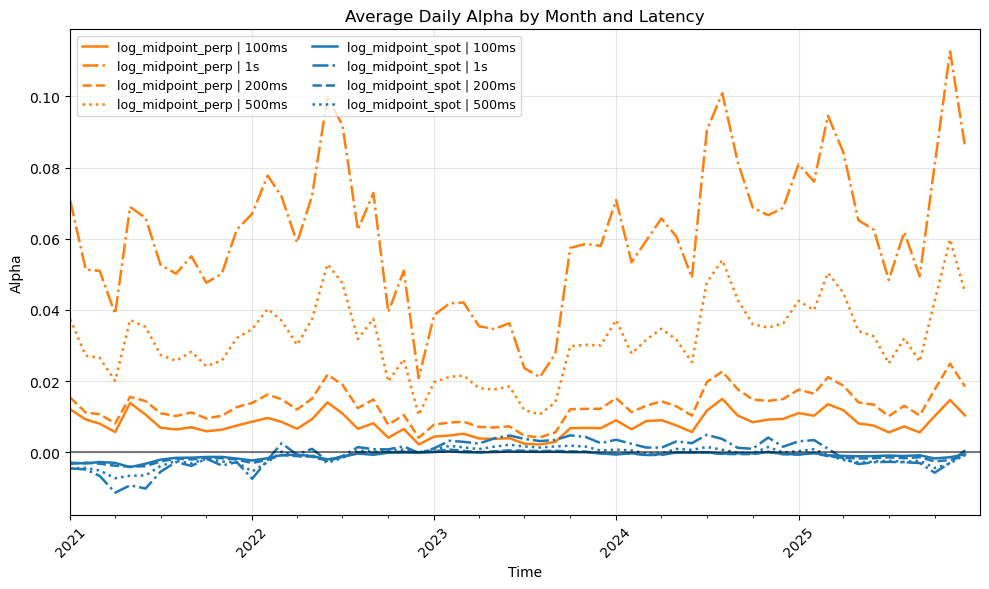

In [ ]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='avg_daily_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting 
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '100ms': '-',
    '200ms': '--',
    '500ms': ':',
    '1s': '-.'
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# format x-axis as proper time series 
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# labels / legend
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

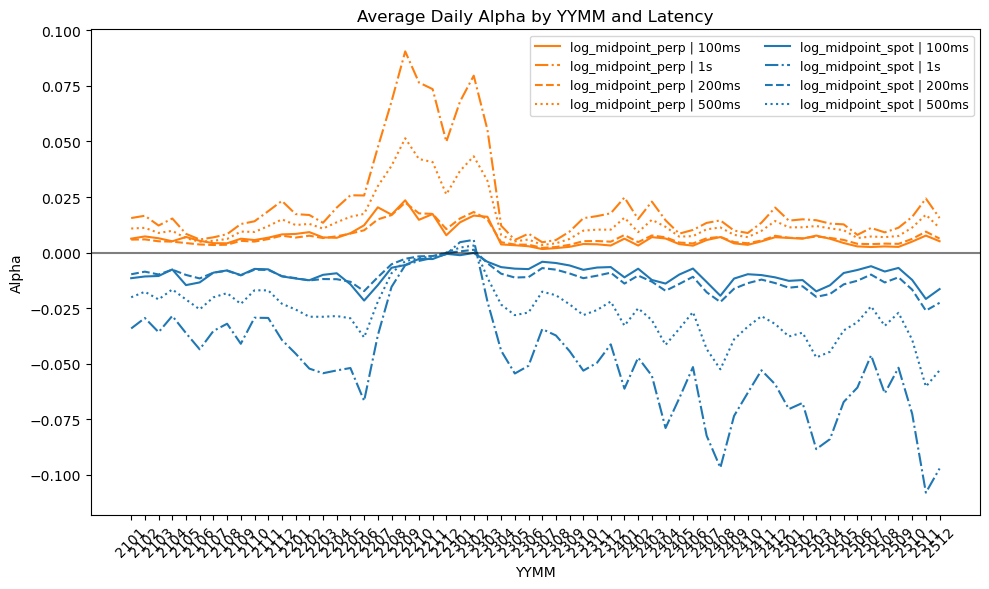

In [ ]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='avg_daily_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '100ms': '-',
    '200ms': '--',
    '500ms': '-.',
    '1s': ':'
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# --- format x-axis as proper time series ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# --- labels / legend ---
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Processing for log-distributed lag base robustness check

In [111]:
periods = [
    ('20210101', '20220101'),
    ('20220101', '20220701'),
    
    ('20220701', '20230301'),
    ('20230301', '20240101'),
    ('20240101', '20250101'),
    ('20250101', '20251231')
]
averages = find_period_mean(results_dict, periods)

In [103]:
averages

[              series        CS  HIS_lower  HIS_upper  HIS_mid   ILS_mid  \
 0  log_midpoint_perp  0.706972   0.182692   0.945688  0.56419  0.366845   
 1  log_midpoint_spot  0.293028   0.817308   0.054312  0.43581  0.633155   
 
   latency  base             period  
 0      1s    10  20210101,20211231  
 1      1s    10  20210101,20211231  ,
               series       CS  HIS_lower  HIS_upper   HIS_mid   ILS_mid  \
 0  log_midpoint_perp  0.41888    0.13715   0.791275  0.464213  0.517707   
 1  log_midpoint_spot  0.58112    0.86285   0.208725  0.535787  0.482293   
 
   latency  base             period  
 0      1s    10  20220101,20221231  
 1      1s    10  20220101,20221231  ,
               series        CS  HIS_lower  HIS_upper   HIS_mid   ILS_mid  \
 0  log_midpoint_perp  0.710097    0.32309   0.871281  0.597185  0.418501   
 1  log_midpoint_spot  0.289903    0.67691   0.128719  0.402815  0.581499   
 
   latency  base             period  
 0      1s    10  20230101,20231231  
 

In [112]:
averages = pd.concat(averages).sort_values(['period', 'latency', 'base'])
averages[averages['series']=='log_midpoint_spot']

,series,CS,HIS_lower,HIS_upper,HIS_mid,ILS_mid,latency,base,period
1,log_midpoint_spot,0.786325,0.943085,0.830428,0.886756,0.699678,100ms,10,"20210101,20220101"
1,log_midpoint_spot,0.914850,0.979472,0.603494,0.791483,0.395636,1s,10,"20210101,20220101"
1,log_midpoint_spot,0.810534,0.954930,0.772685,0.863807,0.611515,200ms,10,"20210101,20220101"
1,log_midpoint_spot,0.895202,0.972814,0.695339,0.834076,0.480544,500ms,10,"20210101,20220101"
1,log_midpoint_spot,0.761298,0.920615,0.854587,0.887601,0.756195,50ms,10,"20210101,20220101"
1,log_midpoint_spot,0.883653,0.969033,0.867588,0.918311,0.629947,100ms,10,"20220101,20220701"
1,log_midpoint_spot,1.003859,0.984167,0.690793,0.837480,0.407297,1s,10,"20220101,20220701"
1,log_midpoint_spot,0.912728,0.975419,0.820775,0.898097,0.541537,200ms,10,"20220101,20220701"
1,log_midpoint_spot,0.969024,0.981517,0.754257,0.867887,0.456393,500ms,10,"20220101,20220701"
1,log_midpoint_spot,0.771505,0.934108,0.874603,0.904356,0.775997,50ms,10,"20220101,20220701"


In [87]:
averages[averages['series']=='log_midpoint_spot']

,series,CS,HIS_lower,HIS_upper,HIS_mid,ILS_mid,latency,base,period
1,log_midpoint_spot,0.350270,0.460121,0.200539,0.330330,0.466309,100ms,1,"20210101,20211231"
1,log_midpoint_spot,0.367624,0.476398,0.202824,0.339611,0.465046,100ms,2,"20210101,20211231"
1,log_midpoint_spot,0.380122,0.488933,0.206178,0.347556,0.460137,100ms,5,"20210101,20211231"
1,log_midpoint_spot,0.377258,0.482663,0.201046,0.341855,0.456812,100ms,10,"20210101,20211231"
1,log_midpoint_spot,0.248884,0.791538,0.072404,0.431971,0.600839,1s,1,"20210101,20211231"
...,...,...,...,...,...,...,...,...,...
1,log_midpoint_spot,0.241592,0.431273,0.067088,0.249180,0.520130,200ms,10,"20250101,20251231"
1,log_midpoint_spot,0.189026,0.558556,0.041951,0.300254,0.630713,500ms,1,"20250101,20251231"
1,log_midpoint_spot,0.190970,0.558985,0.039930,0.299458,0.635111,500ms,2,"20250101,20251231"
1,log_midpoint_spot,0.187601,0.555413,0.037023,0.296218,0.641260,500ms,5,"20250101,20251231"


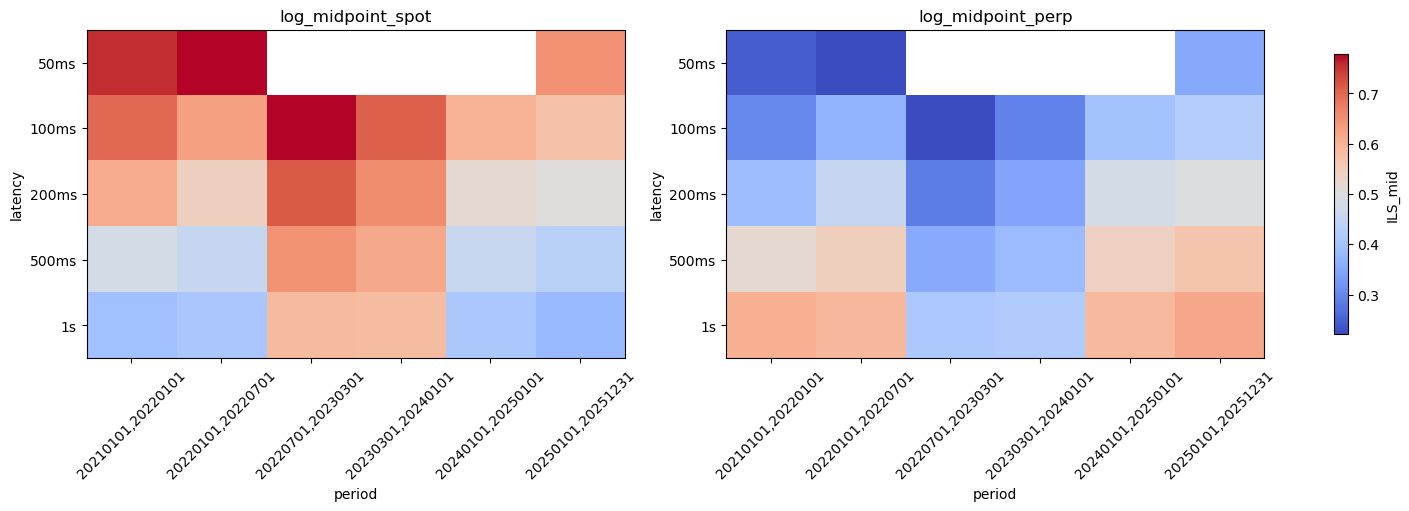

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# Heatmap: periods vs latencies
df = averages.copy()

metric = "ILS_mid"

# make latency ordered
latency_order = ['10ms', '50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, series in zip(axes, ['log_midpoint_spot', 'log_midpoint_perp']):
    sub = df[df['series'] == series].copy()
    pivot = sub.pivot(index='latency', columns='period', values=metric).sort_index()
    
    # set symmetric color scale around 0.5
    max_dev = (pivot - 0.5).abs().max().max()
    vmin = 0.5 - max_dev
    vmax = 0.5 + max_dev

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('period')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()


Plotting the previous results

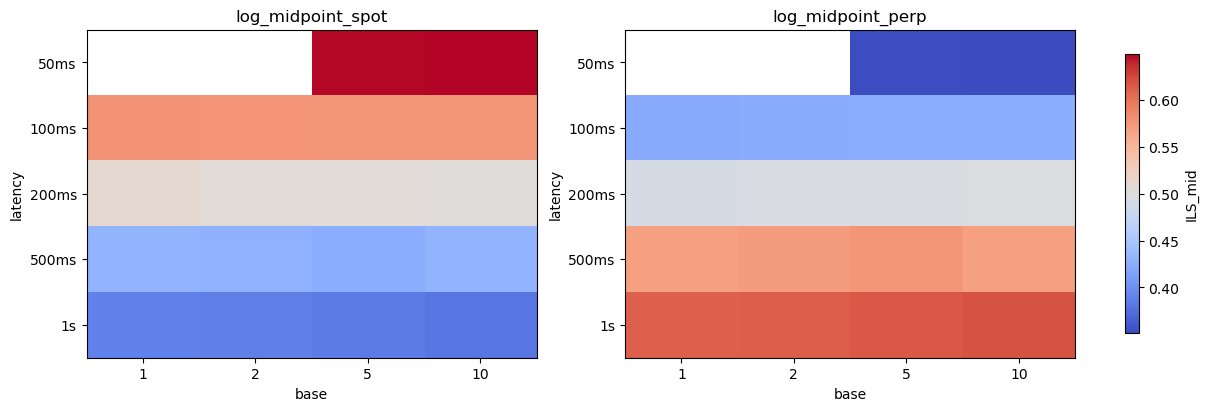

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = averages[averages['period']=='20250101,20251231']
# make latency ordered
latency_order = ['50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

metric = "ILS_mid"

max_dev = (df[metric] - 0.5).abs().max()

vmin = 0.5 - max_dev
vmax = 0.5 + max_dev

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, series in zip(axes, ['log_midpoint_spot', 'log_midpoint_perp']):
    sub = df[df['series'] == series].copy()
    pivot = sub.pivot(index='latency', columns='base', values=metric).sort_index()

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('base')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()

Intraday error correction

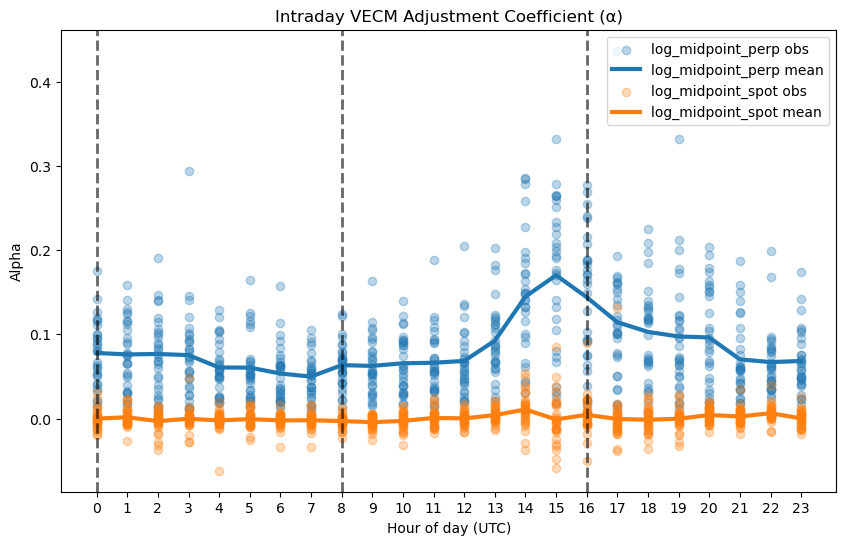

In [7]:
df = results[('1s', 1)].copy()
# ensure datetime
df['interval'] = pd.to_datetime(df['interval'])
# df['alpha'] = df['alpha'].abs()

# extract hour of day
df['hour'] = df['interval'].dt.hour

# mean alpha by hour and series
mean_alpha = (
    df.groupby(['hour','series'])['alpha']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for series, g in df.groupby('series'):
    
    # scatter observations
    ax.scatter(
        g['hour'],
        g['alpha'],
        alpha=0.3,
        label=f"{series} obs"
    )
    
    # mean line
    m = mean_alpha[mean_alpha['series'] == series]
    ax.plot(
        m['hour'],
        m['alpha'],
        linewidth=3,
        label=f"{series} mean"
    )

# funding payment times
funding_times = [0, 8, 16]

for f in funding_times:
    ax.axvline(
        x=f,
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        color='k'
    )

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Alpha")
ax.set_title("Intraday VECM Adjustment Coefficient (α)")
ax.set_xticks(range(24))
ax.legend()

plt.show()

Checking proportion of CS > 0

In [14]:
results_i = results_dict[('1s', 1)].copy()
# pivot to get both CS values in one row
cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# check condition: both > 0
both_positive = (cs_wide > 0).all(axis=1)

# portion of intervals
portion = both_positive.mean()

print(portion)

0.698329974752739


HIS plot

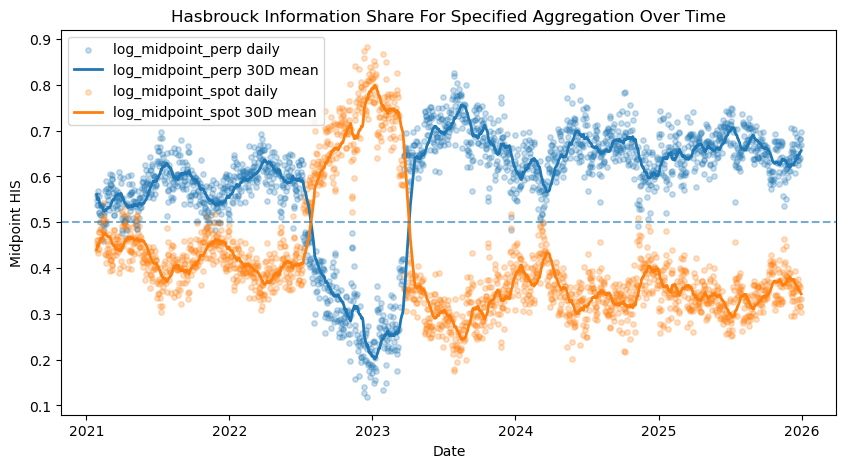

In [20]:
# results_i = results_dict[('1s', 1)].copy()
# # pivot to get both CS values in one row
# cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# # check condition: both > 0
# both_positive = (cs_wide > 0).all(axis=1)

# # portion of intervals
# portion = both_positive.mean()

results_i = results_dict[('1s', 1)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date
results_i = results_i[results_i['interval'].isin(both_positive.index)]

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['HIS_mid']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['HIS_mid'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['HIS_mid'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint HIS')
ax.legend()
plt.title('Hasbrouck Information Share For Specified Aggregation Over Time')
plt.show()

ILS plot

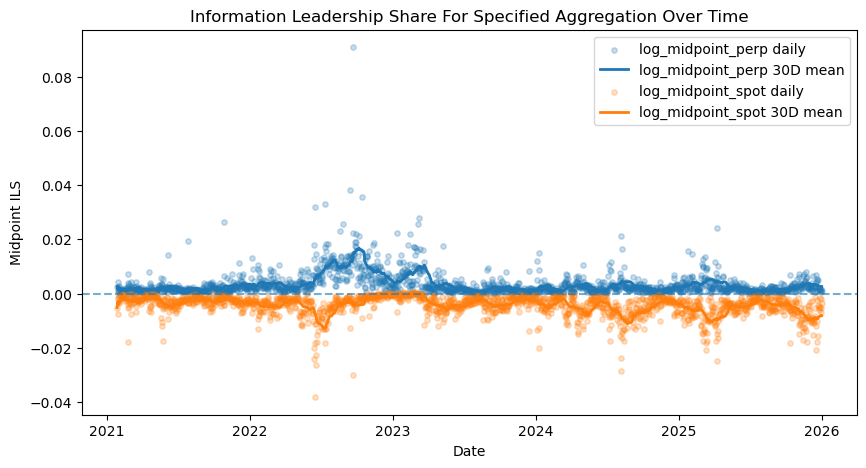

In [18]:
results_i = results_dict[('100ms', 10)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['alpha']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['alpha'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['alpha'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint ILS')
ax.legend()
plt.title('Information Leadership Share For Specified Aggregation Over Time')
plt.show()

### ETH

Fitting the Hasbrouck model

In [11]:
hasbrouck = VECMHasbrouck2('ETHUSDT', 'Binance', 'cm')
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2026, 1, 1)

# differente aggregation levels used
aggs = ['1s', '500ms', '200ms']
# the distribution base for the lags, so 10 means every lag increments by power of 10, so 10, 100, 1000, etc. 
# 1 means every lag is used, 2 means every power of 2, so 2, 4, 8, etc.
lags = [10, 5, 2, 1]

# start date, end date, agg period, subset of days pulled each time, frequency of new model, folder name to save results, prefix for file names, lag distribution base
results, summary = hasbrouck.get_data_multiperiod(start, end, aggs=aggs, interval='1H', period=30, folder_name='vecm_hasbrouck3_eth_cm', prefix='hasbrouck3_eth', lag_is=lags)

File found, reading from file: hasbrouck3_eth_alignedv2_1h_1s_10_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_1s_5_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_1s_2_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_1s_1_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_500ms_10_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_500ms_5_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_500ms_2_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_500ms_1_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_200ms_10_cm_results_20251202_20260101.csv
File found, reading from file: hasbrouck3_eth_alignedv2_1h_200ms_5_cm_results_20251202_20260101.csv
File foun

In [2]:
hasbrouck = VECMHasbrouck2('ETHUSDT', 'Binance', 'cm')
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2025, 12, 31)

# differente aggregation levels used
aggs = ['100ms', '50ms', '10ms']
# the distribution base for the lags, so 10 means every lag increments by power of 10, so 10, 100, 1000, etc. 
# 1 means every lag is used, 2 means every power of 2, so 2, 4, 8, etc.
lags = [10]

# start date, end date, agg period, subset of days pulled each time, frequency of new model, folder name to save results, prefix for file names, lag distribution base
results, summary = hasbrouck.get_data_multiperiod(start, end, aggs=aggs, interval='1H', period=10, folder_name='vecm_hasbrouck3_eth_cm', prefix='hasbrouck3_eth', lag_is=lags)

Processing 11 files...
Processing batch 1/1
Combining results...
Processing 11 files...
Processing batch 1/1
Combining results...
dict_keys([('100ms', 10), ('50ms', 10), ('10ms', 10)])
Processing 11 files...
Processing batch 1/1
Combining results...
Processing 11 files...
Processing batch 1/1
Combining results...
dict_keys([('100ms', 10), ('50ms', 10), ('10ms', 10)])
Processing 11 files...
Processing batch 1/1
Combining results...
Processing 11 files...
Processing batch 1/1
Combining results...
dict_keys([('100ms', 10), ('50ms', 10), ('10ms', 10)])
Processing 11 files...
Processing batch 1/1
Combining results...
Processing 11 files...
Processing batch 1/1
Combining results...
dict_keys([('100ms', 10), ('50ms', 10), ('10ms', 10)])
Processing 11 files...
Processing batch 1/1
Combining results...
Processing 11 files...
Processing batch 1/1
Combining results...
dict_keys([('100ms', 10), ('50ms', 10), ('10ms', 10)])
Processing 11 files...
Processing batch 1/1
Combining results...
Processing

#### Diagnostics

In [7]:
# Sample one full day out of every x days for stale-price diagnostics
# This uses the diagnostic-enabled VECM file without replacing the VECMHasbrouck2
# class already imported elsewhere in this notebook.
from pathlib import Path
import gc

from vecm_hasbrouck2 import (
    VECMHasbrouck2 as StalenessVECMHasbrouck2,
)

staleness_model = StalenessVECMHasbrouck2(
    ticker="ETHUSDT",
    source="Binance",
    cm_um="um",
)

# -------------------------
# Sampling configuration
# -------------------------
diagnostic_start = datetime.datetime(2021, 1, 1)
diagnostic_end = datetime.datetime(2026, 1, 1)

sample_every_days = 30       # Check one day out of every x days
sample_length_days = 1       # Length of each sampled window
sample_offset_days = 0       # Shift the first sampled day, if desired

stale_aggs = ["10ms", "50ms", "100ms"]
stale_after_ms = 100

# False matches the observed-bin structure used by the VECM and is much lighter.
# True creates every calendar-time bin; one 10 ms day is about 8.64 million rows.
fill_gaps = False

output_csv = Path(
    "vecm_hasbrouck2_eth_um/"
    f"eth_fill_age_sample_1_in_{sample_every_days}_days.csv"
)
output_csv.parent.mkdir(parents=True, exist_ok=True)

# -------------------------
# Construct sampled days
# -------------------------
first_sample = (
    pd.Timestamp(diagnostic_start)
    + pd.Timedelta(days=sample_offset_days)
)
latest_sample_start = (
    pd.Timestamp(diagnostic_end)
    - pd.Timedelta(days=sample_length_days)
)

sample_starts = pd.date_range(
    start=first_sample,
    end=latest_sample_start,
    freq=f"{sample_every_days}D",
)

# Resume from the CSV if the cell was interrupted previously.
if output_csv.exists():
    sampled_staleness = pd.read_csv(
        output_csv,
        parse_dates=["sample_start", "sample_end"],
    )
    completed = {
        (pd.Timestamp(row.sample_start), str(row.latency))
        for row in sampled_staleness.itertuples()
    }
    print(f"Loaded {len(sampled_staleness)} completed rows from {output_csv}.")
else:
    sampled_staleness = pd.DataFrame()
    completed = set()

# -------------------------
# Run one sampled day at a time
# -------------------------
for sample_start in sample_starts:
    sample_end = min(
        sample_start + pd.Timedelta(days=sample_length_days),
        pd.Timestamp(diagnostic_end),
    )

    missing_aggs = [
        agg for agg in stale_aggs
        if (pd.Timestamp(sample_start), agg) not in completed
    ]
    if not missing_aggs:
        continue

    print(
        f"Checking {sample_start:%Y-%m-%d} "
        f"for {', '.join(missing_aggs)}..."
    )

    try:
        day_summary = staleness_model.check_staleness(
            start=sample_start,
            end=sample_end,
            aggs=missing_aggs,
            stale_after_ms=stale_after_ms,
            fill_gaps=fill_gaps,
            return_details=False,
            print_summary=False,
        )

        day_summary.insert(0, "sample_start", sample_start)
        day_summary.insert(1, "sample_end", sample_end)
        day_summary.insert(2, "sample_every_days", sample_every_days)

        sampled_staleness = pd.concat(
            [sampled_staleness, day_summary],
            ignore_index=True,
        )

        sampled_staleness = (
            sampled_staleness
            .drop_duplicates(
                subset=["sample_start", "latency"],
                keep="last",
            )
            .sort_values(["sample_start", "latency"])
            .reset_index(drop=True)
        )
        sampled_staleness.to_csv(output_csv, index=False)

        completed.update(
            (pd.Timestamp(sample_start), agg)
            for agg in missing_aggs
        )

    except Exception as exc:
        print(f"Failed for {sample_start:%Y-%m-%d}: {exc}")

    finally:
        gc.collect()

print(f"Saved sampled diagnostics to {output_csv}")

display_columns = [
    col for col in [
        "sample_start",
        "sample_end",
        "latency",
        "diagnostic_basis",
        "n_rows",

        # Price behavior, separate from forward filling
        "neither_change_share",

        # Any forward filling
        "spot_forward_filled_share",
        "perp_forward_filled_share",
        "either_forward_filled_share",
        "both_forward_filled_share",
        "one_sided_forward_filled_share",

        # Forward-filled values older than stale_after_ms
        "spot_fill_stale_share",
        "perp_fill_stale_share",
        "either_fill_stale_share",
        "both_fill_stale_share",
        "one_sided_fill_stale_share",

        # Actual fill-age distribution
        "spot_fill_age_p50_ms",
        "perp_fill_age_p50_ms",
        "spot_fill_age_p95_ms",
        "perp_fill_age_p95_ms",
        "spot_fill_age_p99_ms",
        "perp_fill_age_p99_ms",
        "spot_fill_age_max_ms",
        "perp_fill_age_max_ms",
    ]
    if col in sampled_staleness.columns
]

sampled_staleness[display_columns].to_clipboard()


Loaded 183 completed rows from vecm_hasbrouck2_eth_um\eth_fill_age_sample_1_in_30_days.csv.
Saved sampled diagnostics to vecm_hasbrouck2_eth_um\eth_fill_age_sample_1_in_30_days.csv


In [5]:
day_summary = staleness_model.check_staleness(
    start=sample_start,
    end=sample_end,
    aggs=missing_aggs,
    stale_after_ms=100,
    fill_gaps=False,
    max_fill_gap_ms=None,
    return_details=False,
    print_summary=False,
)

Processing 2 files...
Processing batch 1/1
Combining results...
Processing 2 files...
Processing batch 1/1
Combining results...


<Axes: xlabel='sample_start', ylabel='both_stale_share'>

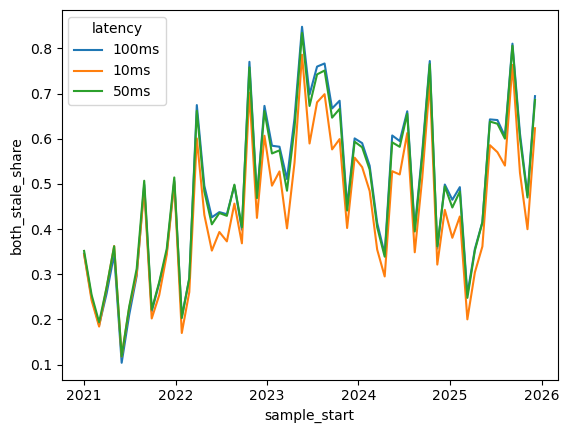

In [3]:
import seaborn as sns
sns.lineplot(data=sampled_staleness, x='sample_start', y='both_stale_share', hue='latency')

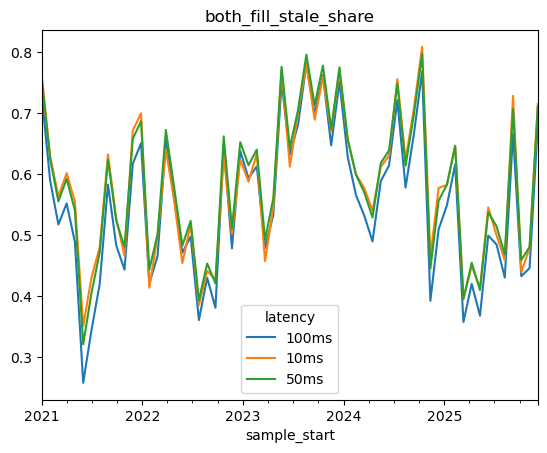

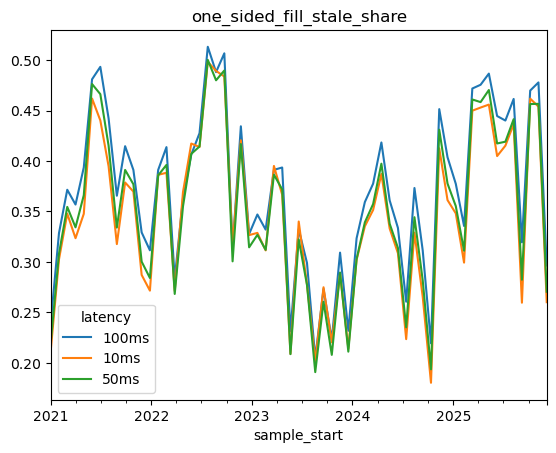

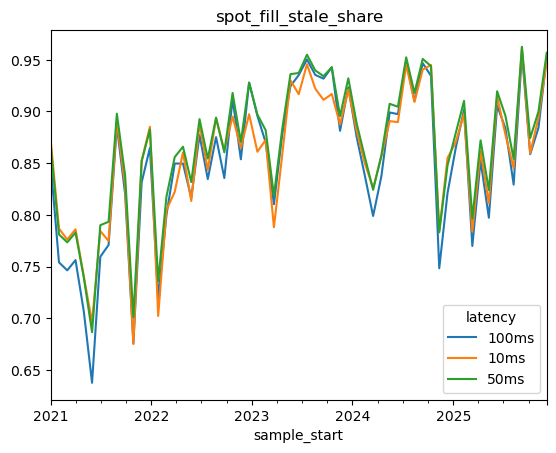

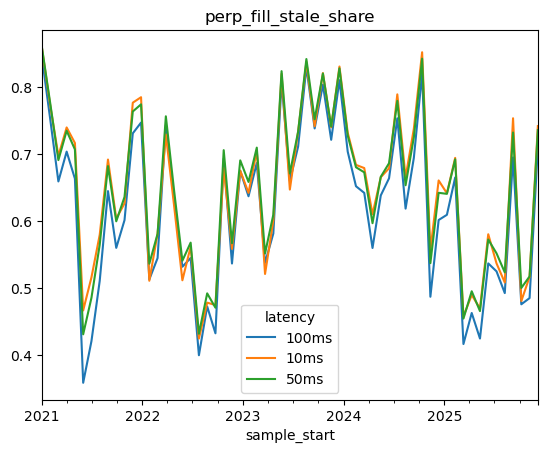

In [3]:
metrics = [
    "both_fill_stale_share",
    "one_sided_fill_stale_share",
    "spot_fill_stale_share",
    "perp_fill_stale_share",
]

for metric in metrics:
    (
        sampled_staleness
        .pivot(
            index="sample_start",
            columns="latency",
            values=metric,
        )
        .plot(title=metric)
    )

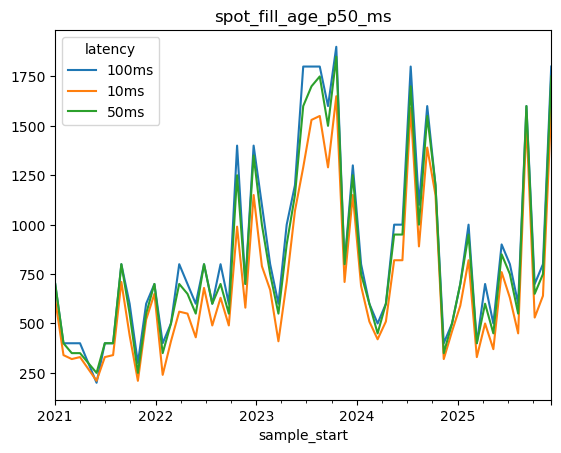

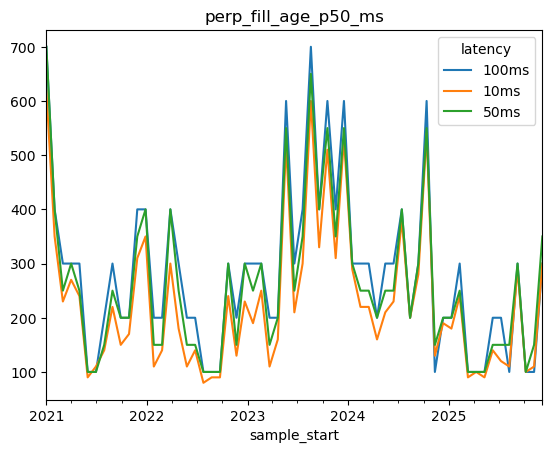

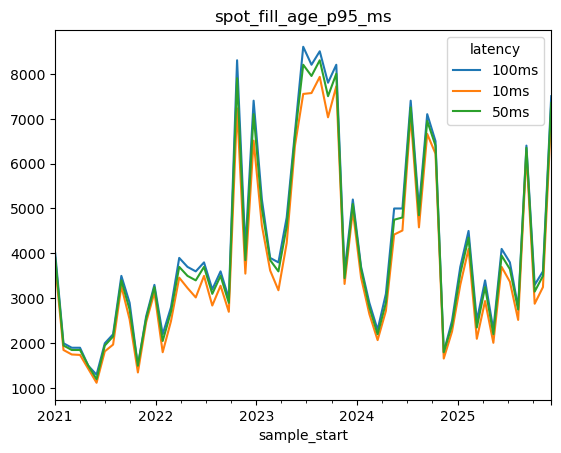

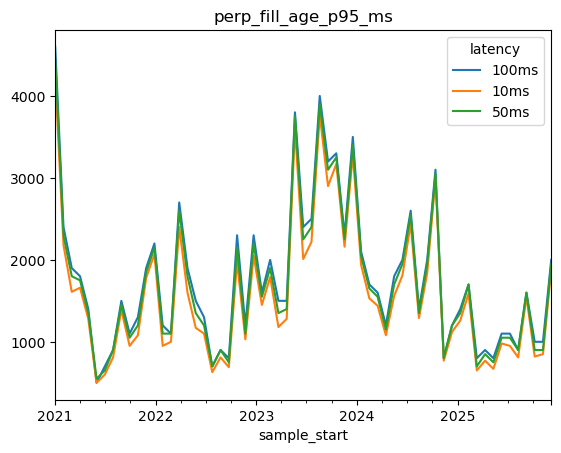

In [4]:
metrics = [
    "spot_fill_age_p50_ms",
    "perp_fill_age_p50_ms",
    "spot_fill_age_p95_ms",
    "perp_fill_age_p95_ms",
]

for metric in metrics:
    (
        sampled_staleness
        .pivot(
            index="sample_start",
            columns="latency",
            values=metric,
        )
        .plot(title=metric)
    )

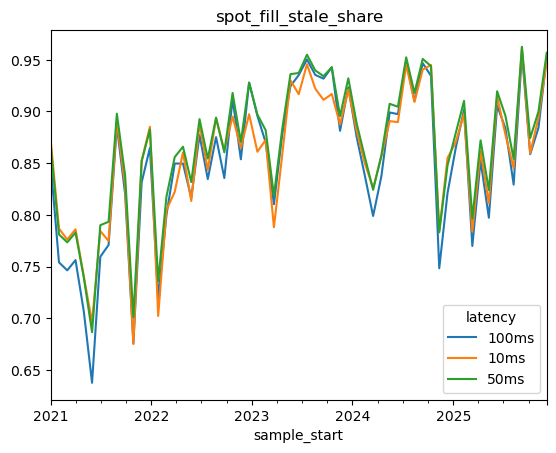

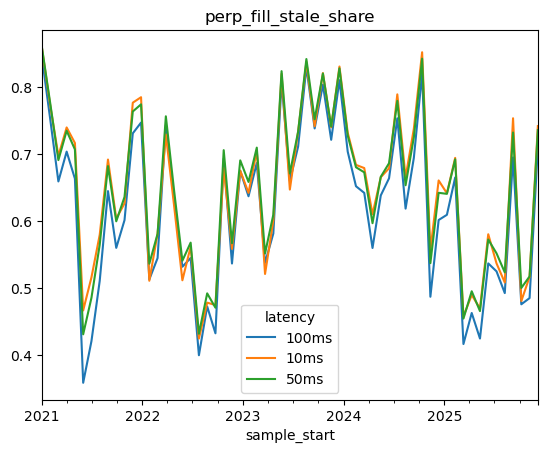

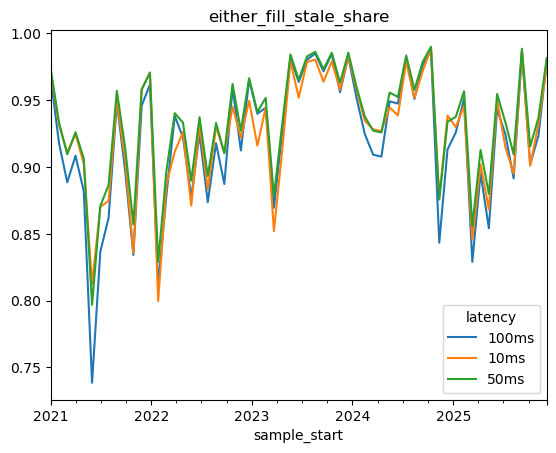

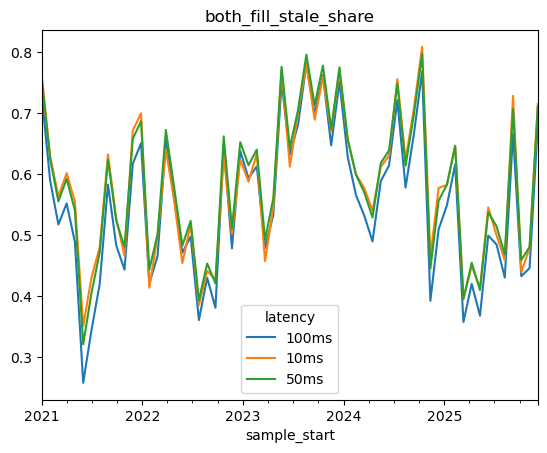

In [9]:
sampled_staleness["spot_only_fill_stale_share"] = (
    sampled_staleness["spot_fill_stale_share"]
    - sampled_staleness["both_fill_stale_share"]
)


sampled_staleness["perp_only_fill_stale_share"] = (
    sampled_staleness["perp_fill_stale_share"]
    - sampled_staleness["both_fill_stale_share"]
)

for metric in [
    "spot_fill_stale_share",
    "perp_fill_stale_share",
    'either_fill_stale_share',
    'both_fill_stale_share',
]:
    (
        sampled_staleness
        .pivot(
            index="sample_start",
            columns="latency",
            values=metric,
        )
        .plot(title=metric)
    )

#### Continue

Reading from saved data rather than pulling new ones

In [114]:
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2025, 12, 31)

# aggs = ['50ms', '1s', '500ms', '200ms', '100ms']
aggs = ['1s', '500ms', '200ms', '100ms', '50ms', '10ms']
lags = [10]

# start date, end date, agg period, frequency of new model, lag distribution base, linear or inverse, file prefix,folder name to find results
linear_res_dict = read_files(start, end, aggs, '1H', lags, 'um', 'hasbrouck3_eth_alignedv2', 'vecm_hasbrouck3_eth_um')
inverse_res_dict = read_files(start, end, aggs, '1H', lags, 'cm', 'hasbrouck3_eth_alignedv2', 'vecm_hasbrouck3_eth_cm')

Pre-processing for 2021-2025 alpha plot

In [115]:
# assuming your dict is called results
wanted = [
    ('10ms', 10),
    ('50ms', 10),
    ('100ms', 10),
    ('200ms', 10),
    ('500ms', 10),
    ('1s', 10),
]

out = []

for (latency, lag) in wanted:
    df = linear_res_dict[(latency, lag)].copy()

    # make sure interval is datetime
    df['interval'] = pd.to_datetime(df['interval'])

    # extract day and yymm
    df['date'] = df['interval'].dt.floor('D')
    df['yymm'] = df['interval'].dt.strftime('%y%m')
    df['year'] = df['date'].dt.year
    df['latency'] = latency
    df['contract_type'] = 'linear'

    # # 1) average alpha within each day (group by date, not yymm)
    # daily_alpha = (
    #     df.groupby(['date', 'latency', 'series'], as_index=False)['alpha']
    #       .median()
    #       .rename(columns={'alpha': 'daily_alpha'})
    # )
    
    # # extract yymm from date for later grouping
    # daily_alpha['yymm'] = daily_alpha['date'].dt.strftime('%y%m')

    # # 2) average the daily values within each month
    # monthly_alpha = (
    #     daily_alpha.groupby(['yymm', 'latency', 'series'], as_index=False)['daily_alpha']
    #                 .median()
    #                 .rename(columns={'daily_alpha': 'monthly_alpha'})
    # )

    out.append(df)

    df = inverse_res_dict[(latency, lag)].copy()

    # make sure interval is datetime
    df['interval'] = pd.to_datetime(df['interval'])

    # extract day and yymm
    df['date'] = df['interval'].dt.floor('D')
    df['yymm'] = df['interval'].dt.strftime('%y%m')
    df['year'] = df['date'].dt.year
    df['latency'] = latency
    df['contract_type'] = 'inverse'
    out.append(df)

# alpha_table = pd.concat(out, ignore_index=True).sort_values(['yymm', 'latency', 'series'])

# # Remove outliers per latency using IQR method
# def remove_outliers_iqr(group):
#     col = 'daily_alpha'
#     Q1 = group[col].quantile(0.25)
#     Q3 = group[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     return group[(group[col] >= lower) & (group[col] <= upper)]

# # alpha_table = alpha_table.groupby('latency', group_keys=False).apply(remove_outliers_iqr)

# print(alpha_table)

In [19]:
results

,interval,series,alpha,beta,CS,HIS_lower,HIS_upper,HIS_mid,ILS_mid,n_obs,date,yymm,year,latency,contract_type
0,2021-01-01 00:00:00,log_midpoint_spot,-0.050502,1.0,0.410444,0.365917,0.303300,0.334608,0.419388,29236,2021-01-01,2101,2021,10ms,linear
1,2021-01-01 00:00:00,log_midpoint_perp,0.035159,-1.0,0.589556,0.634083,0.696700,0.665392,0.580612,29236,2021-01-01,2101,2021,10ms,linear
2,2021-01-01 01:00:00,log_midpoint_spot,-0.005984,1.0,0.497060,0.543147,0.478401,0.510774,0.513713,41793,2021-01-01,2101,2021,10ms,linear
3,2021-01-01 01:00:00,log_midpoint_perp,0.005914,-1.0,0.502940,0.456853,0.521599,0.489226,0.486287,41793,2021-01-01,2101,2021,10ms,linear
4,2021-01-01 02:00:00,log_midpoint_spot,-0.010760,1.0,0.426472,0.376522,0.320358,0.348440,0.418328,24487,2021-01-01,2101,2021,10ms,linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1052327,2025-12-30 22:00:00,log_midpoint_perp,0.067366,-1.0,0.271805,0.035554,0.763517,0.399536,0.640626,1983,2025-12-30,2512,2025,1s,inverse
1052328,2025-12-30 23:00:00,log_midpoint_spot,-0.044419,1.0,0.687818,0.952208,0.197694,0.574951,0.380399,2031,2025-12-30,2512,2025,1s,inverse
1052329,2025-12-30 23:00:00,log_midpoint_perp,0.097866,-1.0,0.312182,0.047792,0.802306,0.425049,0.619601,2031,2025-12-30,2512,2025,1s,inverse
1052330,2025-12-31 00:00:00,log_midpoint_spot,-0.055706,1.0,0.570049,0.919066,0.151044,0.535055,0.464659,2117,2025-12-31,2512,2025,1s,inverse


In [116]:
results = pd.concat(out, ignore_index=True).drop_duplicates()

df = results.copy()

df["interval"] = pd.to_datetime(df["interval"])
df["date"] = pd.to_datetime(df["date"])

spot = (
    df.loc[
        df["series"].eq("log_midpoint_spot"),
        [
            "interval",
            "date",
            "year",
            "latency",
            "contract_type",
            "alpha",
            "CS",
            "HIS_lower",
            "HIS_upper",
            "HIS_mid",
            "ILS_mid",
            "n_obs",
        ],
    ]
    .rename(
        columns={
            "alpha": "alpha_spot",
            "CS": "CS_spot",
            "HIS_lower": "HIS_lower_spot",
            "HIS_upper": "HIS_upper_spot",
            "HIS_mid": "HIS_mid_spot",
            "ILS_mid": "ILS_spot",
        }
    )
    .copy()
)

spot["perp_leadership"] = 0.5 - spot["ILS_spot"]
spot["spot_leads"] = spot["ILS_spot"] > 0.5

In [28]:
ils_check = (
    df.pivot_table(
        index=["interval", "latency", "contract_type"],
        columns="series",
        values="ILS_mid",
        aggfunc="first",
    )
    .dropna()
)

ils_check["ILS_sum"] = (
    ils_check["log_midpoint_spot"]
    + ils_check["log_midpoint_perp"]
)

print(ils_check["ILS_sum"].describe())
print(
    ils_check.loc[
        ~np.isclose(ils_check["ILS_sum"], 1.0, atol=1e-8)
    ].head()
)

count    5.242600e+05
mean     1.000000e+00
std      7.283474e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: ILS_sum, dtype: float64
Empty DataFrame
Columns: [log_midpoint_perp, log_midpoint_spot, ILS_sum]
Index: []


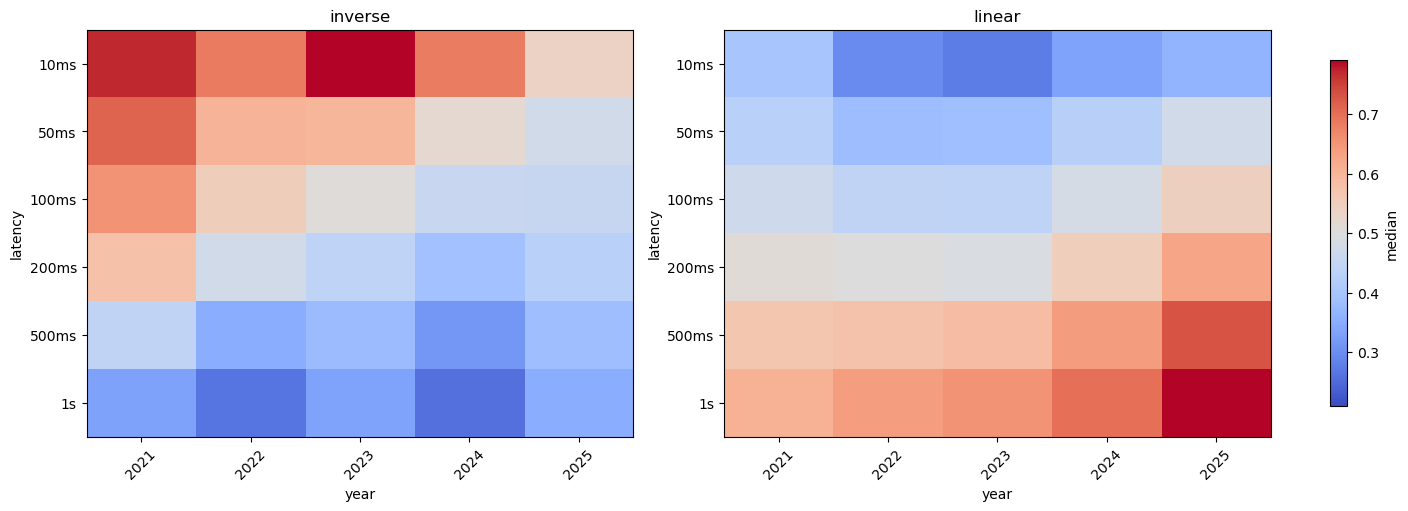

In [ ]:
# using median values instead of mean values
annual_summary = (
    spot.groupby(
        ["contract_type", "year", "latency"],
        observed=True,
    )["ILS_spot"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        p10=lambda x: x.quantile(0.10),
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        count="count",
        share_spot_leads=lambda x: (x > 0.5).mean(),
    )
    .reset_index()
)

annual_summary


# Heatmap: periods vs latencies
df = annual_summary.copy()

metric = "median"

# make latency ordered
latency_order = ['10ms', '50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, series in zip(axes, ['inverse', 'linear']):
    sub = df[df['contract_type'] == series].copy()
    pivot = sub.pivot(index='latency', columns='year', values=metric).sort_index()
    
    # set symmetric color scale around 0.5
    max_dev = (pivot - 0.5).abs().max().max()
    vmin = 0.5 - max_dev
    vmax = 0.5 + max_dev

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('year')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()


In [30]:
def day_block_bootstrap_mean(
    values: pd.Series,
    dates: pd.Series,
    n_boot: int = 2000,
    seed: int = 12345,
) -> dict:
    temp = pd.DataFrame({
        "value": pd.to_numeric(values, errors="coerce"),
        "date": pd.to_datetime(dates),
    }).dropna()

    daily = (
        temp.groupby("date")["value"]
        .agg(day_sum="sum", day_count="count")
    )

    n_days = len(daily)

    if n_days < 2:
        return {
            "estimate": temp["value"].mean(),
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_days": n_days,
            "n_windows": len(temp),
        }

    sums = daily["day_sum"].to_numpy(dtype=float)
    counts = daily["day_count"].to_numpy(dtype=float)

    rng = np.random.default_rng(seed)

    # Shape: n_boot × n_days
    sampled_indices = rng.integers(
        0,
        n_days,
        size=(n_boot, n_days),
    )

    boot_means = (
        sums[sampled_indices].sum(axis=1)
        / counts[sampled_indices].sum(axis=1)
    )

    return {
        "estimate": sums.sum() / counts.sum(),
        "ci_lower": np.quantile(boot_means, 0.025),
        "ci_upper": np.quantile(boot_means, 0.975),
        "n_days": n_days,
        "n_windows": int(counts.sum()),
    }

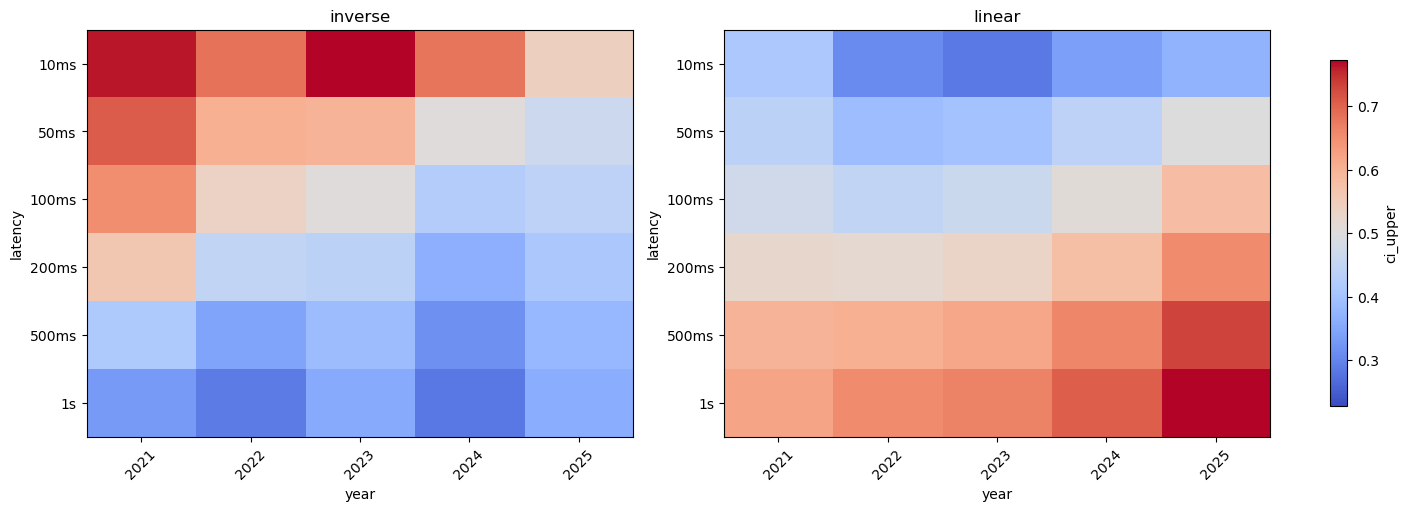

In [125]:
# bootstraping 2000 random hourly points from a year?
bootstrap_rows = []

group_cols = ["contract_type", "year", "latency"]

for keys, group in spot.groupby(group_cols, observed=True):
    contract_type, year, latency = keys

    stats = day_block_bootstrap_mean(
        values=group["ILS_spot"],
        dates=group["date"],
        n_boot=365,
        seed=12345,
    )

    bootstrap_rows.append({
        "contract_type": contract_type,
        "year": year,
        "latency": latency,
        **stats,
        "significant_spot_leadership": (
            stats["ci_lower"] > 0.5
        ),
        "significant_perp_leadership": (
            stats["ci_upper"] < 0.5
        ),
    })

ils_bootstrap = pd.DataFrame(bootstrap_rows)

ils_bootstrap

df = ils_bootstrap.copy()

metric = "ci_upper"

# make latency ordered
latency_order = ['10ms', '50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, series in zip(axes, ['inverse', 'linear']):
    sub = df[df['contract_type'] == series].copy()
    pivot = sub.pivot(index='latency', columns='year', values=metric).sort_index()
    
    # set symmetric color scale around 0.5
    max_dev = (pivot - 0.5).abs().max().max()
    vmin = 0.5 - max_dev
    vmax = 0.5 + max_dev

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('year')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()

In [ ]:
ils_bootstrap
# so far results are pretty much in line with using mean across whole year

,contract_type,year,latency,estimate,ci_lower,ci_upper,n_days,n_windows,significant_spot_leadership,significant_perp_leadership
0,inverse,2021,100ms,0.626254,0.621979,0.630667,365,9461,True,False
1,inverse,2021,10ms,0.725386,0.721105,0.729722,365,9221,True,False
2,inverse,2021,1s,0.346385,0.340080,0.352661,365,8746,False,True
3,inverse,2021,200ms,0.547449,0.541223,0.553474,365,8746,True,False
4,inverse,2021,500ms,0.419165,0.411964,0.426282,365,8746,False,True
5,inverse,2021,50ms,0.676190,0.672370,0.680093,365,9461,True,False
6,inverse,2022,100ms,0.524470,0.518214,0.530749,365,8759,True,False
7,inverse,2022,10ms,0.655019,0.650137,0.659989,365,8759,True,False
8,inverse,2022,1s,0.308812,0.302716,0.314693,365,8759,False,True
9,inverse,2022,200ms,0.449052,0.441667,0.456383,365,8759,False,True


In [ ]:
import numpy as np
import pandas as pd

df["interval"] = pd.to_datetime(df["interval"])

spot_raw = df.loc[
    df["series"].eq("log_midpoint_spot")
].copy()

keys = [
    "interval",
    "latency",
    "contract_type",
]

# Prefer valid estimates, then the version with the most observations.
spot_raw["_valid"] = (
    np.isfinite(spot_raw["ILS_mid"])
    & np.isfinite(spot_raw["CS"])
).astype(int)

spot_clean = (
    spot_raw
    .sort_values(
        keys + ["_valid", "n_obs"],
        ascending=[True, True, True, False, False],
    )
    .drop_duplicates(
        subset=keys,
        keep="first",
    )
    .drop(columns="_valid")
    .copy()
)

assert not spot_clean.duplicated(keys).any()

In [46]:
linear = (
    spot_clean.loc[
        spot_clean["contract_type"].eq("linear"),
        ["interval", "latency", "ILS_mid"],
    ]
    .rename(columns={"ILS_mid": "ILS_spot_linear"})
)

inverse = (
    spot_clean.loc[
        spot_clean["contract_type"].eq("inverse"),
        ["interval", "latency", "ILS_mid"],
    ]
    .rename(columns={"ILS_mid": "ILS_spot_inverse"})
)

paired = inverse.merge(
    linear,
    on=["interval", "latency"],
    how="inner",
    validate="one_to_one",
)

paired["date"] = paired["interval"].dt.normalize()
paired["year"] = paired["interval"].dt.year

paired["contract_difference"] = (
    paired["ILS_spot_inverse"]
    - paired["ILS_spot_linear"]
)

In [48]:
contract_test_rows = []

for keys, group in paired.groupby(
    ["year", "latency"],
    observed=True,
):
    year, latency = keys

    stats = day_block_bootstrap_mean(
        values=group["contract_difference"],
        dates=group["date"],
        n_boot=2000,
        seed=12345,
    )

    contract_test_rows.append({
        "year": year,
        "latency": latency,
        **stats,
        "significant_difference": (
            (stats["ci_lower"] > 0)
            or (stats["ci_upper"] < 0)
        ),
    })

contract_difference_test = pd.DataFrame(contract_test_rows)

contract_difference_test

,year,latency,estimate,ci_lower,ci_upper,n_days,n_windows,significant_difference
0,2021,100ms,0.153868,0.149263,0.158762,355,8505,True
1,2021,10ms,0.320220,0.316289,0.324041,345,8264,True
2,2021,1s,-0.264588,-0.275734,-0.253512,365,8745,True
3,2021,200ms,0.025715,0.018410,0.032977,365,8745,True
4,2021,500ms,-0.170443,-0.181497,-0.159792,365,8745,True
5,2021,50ms,0.240524,0.236978,0.244269,355,8505,True
6,2022,100ms,0.077973,0.071462,0.084451,365,8758,True
7,2022,10ms,0.351695,0.345262,0.358160,365,8758,True
8,2022,1s,-0.339292,-0.349677,-0.329148,365,8758,True
9,2022,200ms,-0.063068,-0.071458,-0.054524,365,8758,True


In [49]:
wide = (
    df.pivot_table(
        index=[
            "interval",
            "date",
            "year",
            "latency",
            "contract_type",
        ],
        columns="series",
        values=["alpha", "CS", "ILS_mid", "n_obs"],
        aggfunc="first",
    )
)

wide.columns = [
    f"{metric}_{series.replace('log_midpoint_', '')}"
    for metric, series in wide.columns
]

wide = wide.reset_index()

In [50]:
wide["conventional_alpha_signs"] = (
    (wide["alpha_spot"] < 0)
    & (wide["alpha_perp"] > 0)
)

wide["CS_spot_in_unit_interval"] = (
    wide["CS_spot"].between(0, 1)
)

wide["finite_shares"] = (
    np.isfinite(wide["CS_spot"])
    & np.isfinite(wide["ILS_mid_spot"])
)

In [ ]:
diagnostic_summary = (
    wide.groupby(
        ["contract_type", "year", "latency"],
        observed=True,
    )
    .agg(
        n_windows=("interval", "size"),
        conventional_alpha_share=(
            "conventional_alpha_signs",
            "mean",
        ),
        CS_in_range_share=(
            "CS_spot_in_unit_interval",
            "mean",
        ),
        finite_share=(
            "finite_shares",
            "mean",
        ),
        median_n_obs=(
            "n_obs_spot",
            "median",
        ),
    )
    .reset_index()
)

diagnostic_summary
# the model actually breaks down a bit for longer latencies

,contract_type,year,latency,n_windows,conventional_alpha_share,CS_in_range_share,finite_share,median_n_obs
0,inverse,2021,100ms,8746,0.990624,0.990853,1.0,16107.5
1,inverse,2021,10ms,8745,0.988451,0.988679,1.0,28533.0
2,inverse,2021,1s,8746,0.803796,0.803910,1.0,3527.0
3,inverse,2021,200ms,8746,0.962954,0.963069,1.0,11674.0
4,inverse,2021,500ms,8746,0.864281,0.864395,1.0,6431.0
5,inverse,2021,50ms,8746,0.985479,0.985708,1.0,20601.0
6,inverse,2022,100ms,8759,0.953305,0.953419,1.0,10235.0
7,inverse,2022,10ms,8759,0.989040,0.989268,1.0,16722.0
8,inverse,2022,1s,8759,0.685923,0.685923,1.0,3227.0
9,inverse,2022,200ms,8759,0.897591,0.897705,1.0,8044.0


In [52]:
cs_distribution = (
    wide.groupby(
        ["contract_type", "year", "latency"],
        observed=True,
    )["CS_spot"]
    .agg(
        mean="mean",
        median="median",
        p05=lambda x: x.quantile(0.05),
        p95=lambda x: x.quantile(0.95),
        outside_unit_interval=lambda x: (
            ~x.between(0, 1)
        ).mean(),
    )
    .reset_index()
)

In [53]:
cs_distribution

,contract_type,year,latency,mean,median,p05,p95,outside_unit_interval
0,inverse,2021,100ms,0.588878,0.583373,0.364409,0.828512,0.009147
1,inverse,2021,10ms,0.508682,0.494376,0.290637,0.743542,0.011321
2,inverse,2021,1s,0.815501,0.798342,0.436464,1.257363,0.196090
3,inverse,2021,200ms,0.653685,0.641978,0.390269,0.957083,0.036931
4,inverse,2021,500ms,0.765397,0.745399,0.417543,1.179770,0.135605
5,inverse,2021,50ms,0.560122,0.546758,0.325145,0.821917,0.014292
6,inverse,2022,100ms,0.668291,0.650374,0.404813,0.989950,0.046581
7,inverse,2022,10ms,0.525734,0.507545,0.318218,0.784213,0.010732
8,inverse,2022,1s,0.895009,0.876924,0.495934,1.352618,0.314077
9,inverse,2022,200ms,0.737329,0.716112,0.427200,1.110217,0.102295


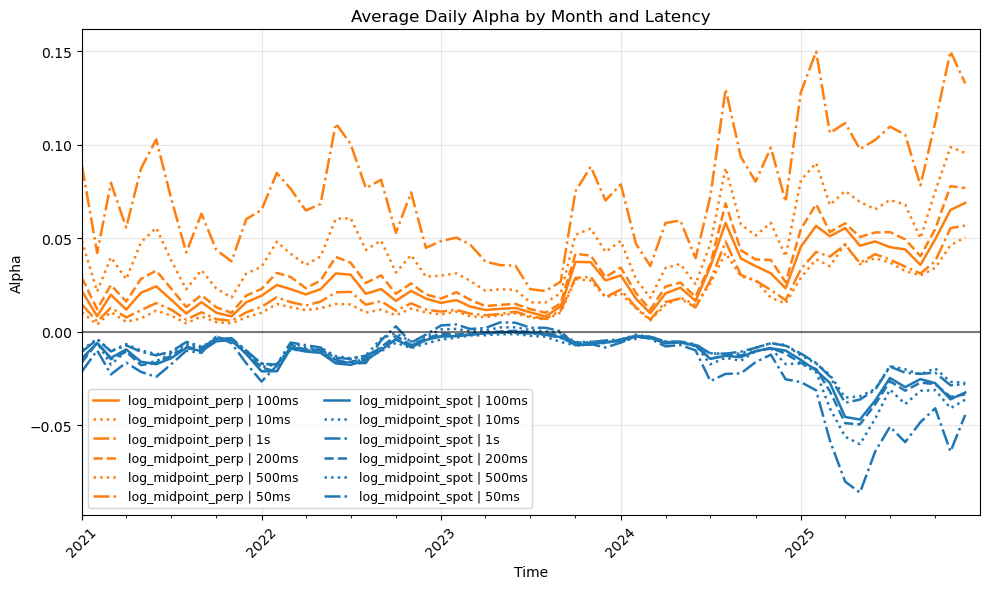

In [5]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='monthly_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting 
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '10ms': ':',
    '50ms': '-.',
    '100ms': '-',
    '200ms': '--',
    '500ms': ':',
    '1s': '-.',
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# format x-axis as proper time series 
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# labels / legend
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

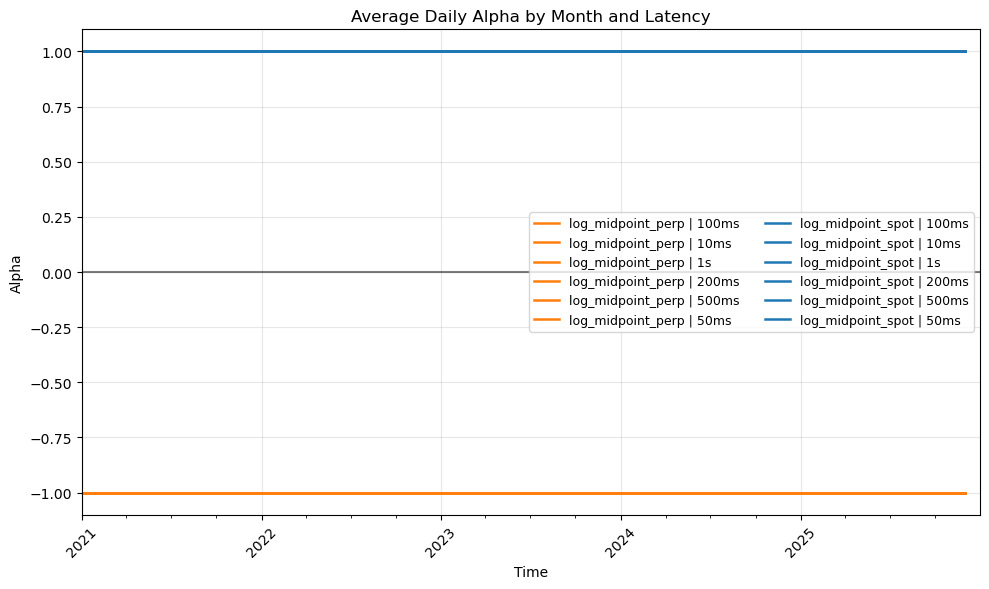

In [ ]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='monthly_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '100ms': '-',
    '200ms': '--',
    '500ms': '-.',
    '1s': ':'
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        # linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# --- format x-axis as proper time series ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# --- labels / legend ---
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Processing for log-distributed lag base robustness check

In [122]:
periods = [
    ('20210101', '20220101'),
    ('20220101', '20230101'),
    ('20230101', '20240101'),
    ('20240101', '20250101'),
    ('20250101', '20251231')
]
averages = find_period_mean(inverse_res_dict, periods)

In [123]:
averages = pd.concat(averages).sort_values(['period', 'latency', 'base'])
averages[averages['series']=='log_midpoint_spot']

,series,CS,HIS_lower,HIS_upper,HIS_mid,ILS_mid,latency,base,period
1,log_midpoint_spot,0.586657,0.837684,0.554364,0.696024,0.626256,100ms,10,"20210101,20220101"
1,log_midpoint_spot,0.508073,0.727045,0.676173,0.701609,0.725387,10ms,10,"20210101,20220101"
1,log_midpoint_spot,0.815478,0.964423,0.331367,0.647895,0.346401,1s,10,"20210101,20220101"
1,log_midpoint_spot,0.653683,0.892875,0.495134,0.694005,0.547453,200ms,10,"20210101,20220101"
1,log_midpoint_spot,0.765373,0.944510,0.414813,0.679662,0.419180,500ms,10,"20210101,20220101"
1,log_midpoint_spot,0.558028,0.791278,0.612944,0.702111,0.676191,50ms,10,"20210101,20220101"
1,log_midpoint_spot,0.668349,0.891498,0.489538,0.690518,0.524500,100ms,10,"20220101,20230101"
1,log_midpoint_spot,0.525760,0.702361,0.608012,0.655186,0.655032,10ms,10,"20220101,20230101"
1,log_midpoint_spot,0.895074,0.976938,0.341866,0.659402,0.308852,1s,10,"20220101,20230101"
1,log_midpoint_spot,0.737375,0.932445,0.446633,0.689539,0.449068,200ms,10,"20220101,20230101"


Plotting the previous results

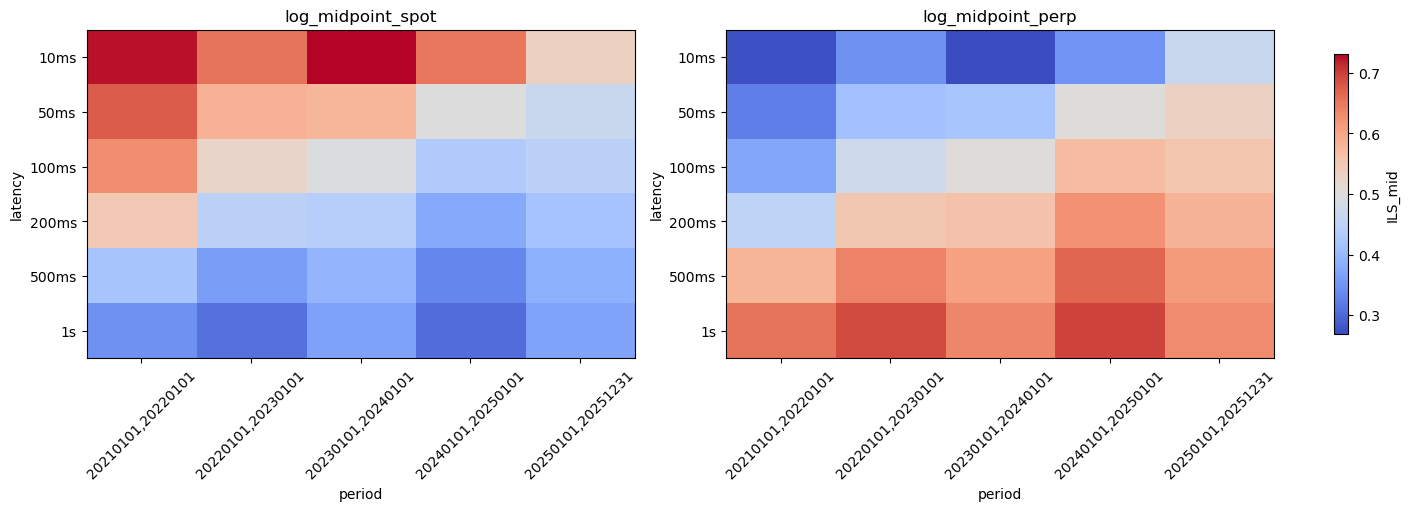

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

# Heatmap: periods vs latencies
df = averages.copy()

metric = "ILS_mid"

# make latency ordered
latency_order = ['10ms', '50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, series in zip(axes, ['log_midpoint_spot', 'log_midpoint_perp']):
    sub = df[df['series'] == series].copy()
    pivot = sub.pivot(index='latency', columns='period', values=metric).sort_index()
    
    # set symmetric color scale around 0.5
    max_dev = (pivot - 0.5).abs().max().max()
    vmin = 0.5 - max_dev
    vmax = 0.5 + max_dev

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('period')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()


Intraday error correction

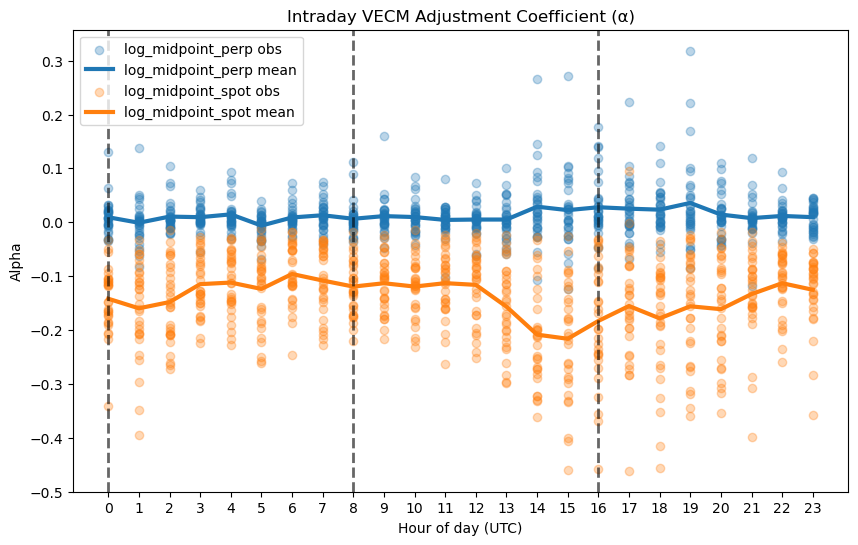

In [9]:
df = results[('1s', 1)].copy()
# ensure datetime
df['interval'] = pd.to_datetime(df['interval'])
# df['alpha'] = df['alpha'].abs()

# extract hour of day
df['hour'] = df['interval'].dt.hour

# mean alpha by hour and series
mean_alpha = (
    df.groupby(['hour','series'])['alpha']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for series, g in df.groupby('series'):
    
    # scatter observations
    ax.scatter(
        g['hour'],
        g['alpha'],
        alpha=0.3,
        label=f"{series} obs"
    )
    
    # mean line
    m = mean_alpha[mean_alpha['series'] == series]
    ax.plot(
        m['hour'],
        m['alpha'],
        linewidth=3,
        label=f"{series} mean"
    )

# funding payment times
funding_times = [0, 8, 16]

for f in funding_times:
    ax.axvline(
        x=f,
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        color='k'
    )

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Alpha")
ax.set_title("Intraday VECM Adjustment Coefficient (α)")
ax.set_xticks(range(24))
ax.legend()

plt.show()

Checking proportion of CS > 0

In [10]:
results_i = results_dict[('1s', 1)].copy()
# pivot to get both CS values in one row
cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# check condition: both > 0
both_positive = (cs_wide > 0).all(axis=1)

# portion of intervals
portion = both_positive.mean()

print(portion)

0.6478454680534919


HIS plot

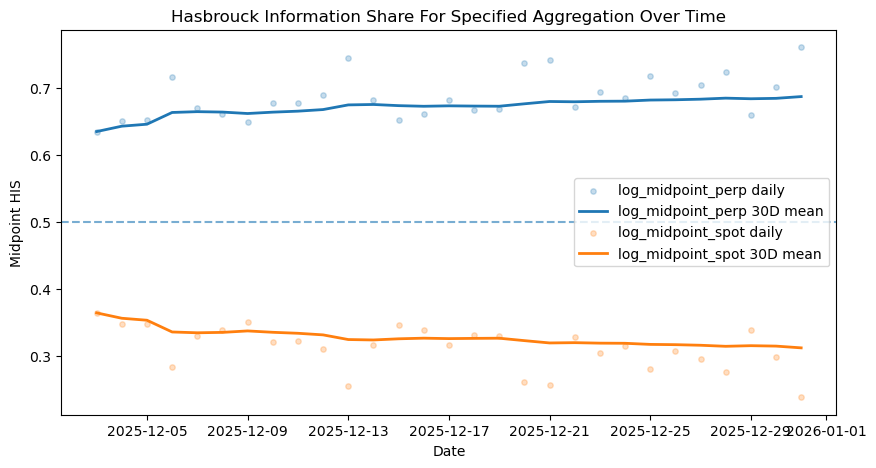

In [11]:
# results_i = results_dict[('1s', 1)].copy()
# # pivot to get both CS values in one row
# cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# # check condition: both > 0
# both_positive = (cs_wide > 0).all(axis=1)

# # portion of intervals
# portion = both_positive.mean()

results_i = results_dict[('1s', 1)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date
results_i = results_i[results_i['interval'].isin(both_positive.index)]

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['HIS_mid']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['HIS_mid'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['HIS_mid'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint HIS')
ax.legend()
plt.title('Hasbrouck Information Share For Specified Aggregation Over Time')
plt.show()

ILS plot

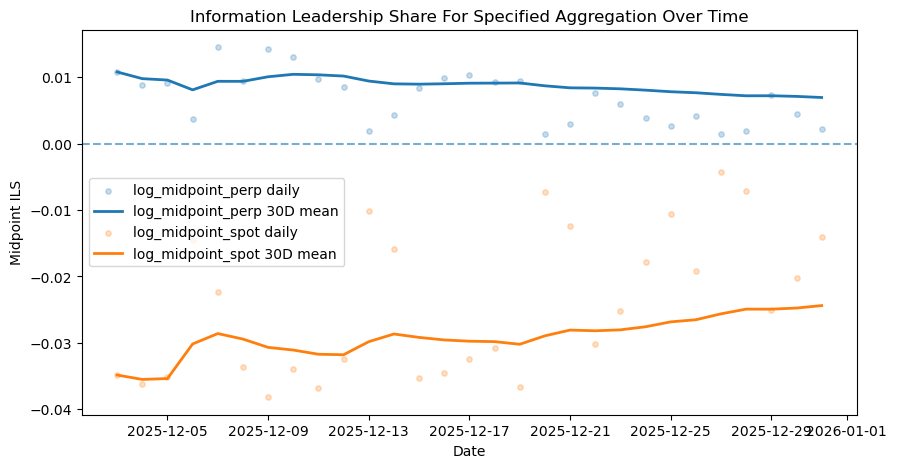

In [12]:
results_i = results_dict[('100ms', 10)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['alpha']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['alpha'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['alpha'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint ILS')
ax.legend()
plt.title('Information Leadership Share For Specified Aggregation Over Time')
plt.show()

### Sampling Diagnostics

In [65]:
import trade_activity_diagnostics
import importlib
importlib.reload(trade_activity_diagnostics)
from trade_activity_diagnostics import (
    run_sampled_trade_activity,
    annual_activity_summary,
)

output_file = "eth_sampled_trade_activity.csv"

In [66]:
linear_activity = run_sampled_trade_activity(
    symbol="ETHUSDT",
    source="Binance",
    cm_um="um",
    contract_type="linear",
    start="2021-01-01",
    end="2026-01-01",  # end is exclusive
    freqs=[
        "10ms",
        "50ms",
        "100ms",
        "200ms",
        "500ms",
        "1s",
    ],
    sample_every_days=30,
    sample_days=1,
    window="1h",
    n_jobs=10,
    output_csv=output_file,
    resume=True,
)

inverse_activity = run_sampled_trade_activity(
    symbol="ETHUSDT",
    source="Binance",
    cm_um="cm",
    contract_type="inverse",
    start="2021-01-01",
    end="2026-01-01",
    freqs=[
        "10ms",
        "50ms",
        "100ms",
        "200ms",
        "500ms",
        "1s",
    ],
    sample_every_days=30,
    sample_days=1,
    window="1h",
    n_jobs=10,
    output_csv=output_file,
    resume=True,
)

Loading linear data for 2021-01-01 through 2021-01-01
Processing 1 files...
Processing batch 1/1


Combining results...
Processing 1 files...
Processing batch 1/1
Combining results...
  Calculating 10ms activity diagnostics
  Calculating 50ms activity diagnostics
  Calculating 100ms activity diagnostics
  Calculating 200ms activity diagnostics
  Calculating 500ms activity diagnostics
  Calculating 1s activity diagnostics
Loading linear data for 2021-01-31 through 2021-01-31
Processing 1 files...
Processing batch 1/1
Combining results...
Processing 1 files...
Processing batch 1/1
Combining results...
  Calculating 10ms activity diagnostics
  Calculating 50ms activity diagnostics
  Calculating 100ms activity diagnostics
  Calculating 200ms activity diagnostics
  Calculating 500ms activity diagnostics
  Calculating 1s activity diagnostics
Loading linear data for 2021-03-02 through 2021-03-02
Processing 1 files...
Processing batch 1/1
Combining results...
Processing 1 files...
Processing batch 1/1
Combining results...
  Calculating 10ms activity diagnostics
  Calculating 50ms activity d

In [67]:
activity = pd.read_csv(
    output_file,
    parse_dates=[
        "window_start",
        "date",
        "sample_start",
        "sample_end",
    ],
)

In [68]:
annual_activity = annual_activity_summary(activity)

annual_activity[
    [
        "contract_type",
        "year",
        "latency",
        "perp_to_spot_observed_bin_ratio",
        "perp_to_spot_price_change_ratio",
        "spot_forward_fill_share",
        "perp_forward_fill_share",
        "spot_median_interupdate_ms",
        "perp_median_interupdate_ms",
    ]
]

,contract_type,year,latency,perp_to_spot_observed_bin_ratio,perp_to_spot_price_change_ratio,spot_forward_fill_share,perp_forward_fill_share,spot_median_interupdate_ms,perp_median_interupdate_ms
0,inverse,2021,100ms,0.343753,0.326049,0.126741,0.706305,200.0,400.0
1,inverse,2021,10ms,0.359701,0.332057,0.224614,0.718652,80.0,60.0
2,inverse,2021,1s,0.614227,0.528272,0.022124,0.403482,1000.0,1000.0
3,inverse,2021,200ms,0.381829,0.353020,0.098548,0.664317,200.0,600.0
4,inverse,2021,500ms,0.483442,0.430153,0.053894,0.550551,500.0,1000.0
5,inverse,2021,50ms,0.328254,0.317800,0.153218,0.725430,100.0,250.0
6,inverse,2022,100ms,0.378168,0.422897,0.131321,0.701189,200.0,300.0
7,inverse,2022,10ms,0.466529,0.478430,0.236164,0.692070,80.0,40.0
8,inverse,2022,1s,0.522184,0.548666,0.033747,0.509651,1000.0,1000.0
9,inverse,2022,200ms,0.388783,0.430613,0.104080,0.678214,200.0,600.0


In [69]:
spot_ils = (
    results.loc[
        results["series"].eq("log_midpoint_spot"),
        [
            "interval",
            "latency",
            "contract_type",
            "ILS_mid",
        ],
    ]
    .rename(columns={
        "interval": "window_start",
        "ILS_mid": "ILS_spot",
    })
    .copy()
)

spot_ils["window_start"] = pd.to_datetime(
    spot_ils["window_start"]
)

# Remove repeated multiperiod boundaries.
spot_ils = spot_ils.drop_duplicates(
    subset=[
        "window_start",
        "latency",
        "contract_type",
    ],
    keep="first",
)

activity_analysis = spot_ils.merge(
    activity,
    on=[
        "window_start",
        "latency",
        "contract_type",
    ],
    how="inner",
    validate="one_to_one",
)

activity_analysis["perp_leadership"] = (
    0.5 - activity_analysis["ILS_spot"]
)

In [70]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula=(
        "perp_leadership ~ "
        "log_perp_to_spot_observed_bin_ratio "
        "+ C(year)"
    ),
    data=activity_analysis,
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": activity_analysis["date"],
    },
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        perp_leadership   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     14.93
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           1.66e-09
Time:                        22:57:59   Log-Likelihood:                 5053.2
No. Observations:               17490   AIC:                        -1.009e+04
Df Residuals:                   17484   BIC:                        -1.005e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [126]:
frequency_results = []

for (contract_type, latency), subset in activity_analysis.groupby(
    ["contract_type", "latency"],
    observed=True,
):
    if len(subset) < 100:
        continue

    fitted = smf.ols(
        formula=(
            "perp_leadership ~ "
            "log_perp_to_spot_observed_bin_ratio "
            "+ C(year)"
        ),
        data=subset,
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": subset["date"],
        },
    )

    variable = "log_perp_to_spot_observed_bin_ratio"

    frequency_results.append({
        "contract_type": contract_type,
        "latency": latency,
        "coefficient": fitted.params.get(variable),
        'constant': fitted.params.get('Intercept'),
        "standard_error": fitted.bse.get(variable),
        "p_value": fitted.pvalues.get(variable),
        "ci_lower": fitted.conf_int().loc[variable, 0],
        "ci_upper": fitted.conf_int().loc[variable, 1],
        "n_obs": int(fitted.nobs),
        "r_squared": fitted.rsquared,
    })

frequency_results = pd.DataFrame(frequency_results)
frequency_results

,contract_type,latency,coefficient,constant,standard_error,p_value,ci_lower,ci_upper,n_obs,r_squared
0,inverse,100ms,0.003112,-0.138072,0.013314,0.815203,-0.022983,0.029207,1464,0.286285
1,inverse,10ms,0.020609,-0.224230,0.015140,0.173456,-0.009066,0.050283,1464,0.424799
2,inverse,1s,0.034094,0.171964,0.022730,0.133621,-0.010456,0.078644,1464,0.026347
3,inverse,200ms,0.022727,-0.036033,0.019359,0.240413,-0.015216,0.060670,1464,0.157564
4,inverse,500ms,0.024698,0.104882,0.020274,0.223137,-0.015038,0.064434,1464,0.040204
5,inverse,50ms,0.000635,-0.194853,0.013582,0.962682,-0.025984,0.027255,1464,0.334022
6,linear,100ms,-0.020868,0.041103,0.019251,0.278372,-0.058599,0.016864,1439,0.232749
7,linear,10ms,0.063486,0.071260,0.016018,0.000074,0.032091,0.094881,1439,0.262203
8,linear,1s,-0.022324,-0.096443,0.050608,0.659123,-0.121515,0.076866,1463,0.101033
9,linear,200ms,-0.046094,-0.001627,0.021200,0.029686,-0.087645,-0.004543,1463,0.210662


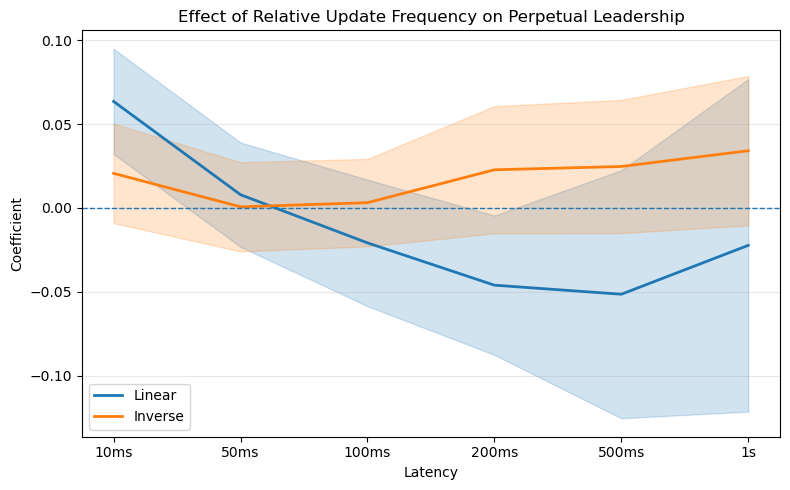

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = frequency_results.copy()

latency_order = ["10ms", "50ms", "100ms", "200ms", "500ms", "1s"]
plot_df["latency"] = pd.Categorical(
    plot_df["latency"],
    categories=latency_order,
    ordered=True,
)

plot_df = plot_df.sort_values(["contract_type", "latency"])

x = np.arange(len(latency_order))

fig, ax = plt.subplots(figsize=(8, 5))

for contract in ["linear", "inverse"]:
    sub = plot_df.loc[plot_df["contract_type"] == contract].copy()
    sub = sub.set_index("latency").reindex(latency_order).reset_index()

    y = sub["coefficient"].to_numpy()
    lower = sub["ci_lower"].to_numpy()
    upper = sub["ci_upper"].to_numpy()

    line, = ax.plot(
        x,
        y,
        linewidth=2,
        label=contract.capitalize(),
    )

    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.2,
        color=line.get_color(),
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(latency_order)
ax.set_xlabel("Latency")
ax.set_ylabel("Coefficient")
ax.set_title("Effect of Relative Update Frequency on Perpetual Leadership")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Sampled lag-order and Johansen-rank diagnostics

This diagnostic samples one day per year by default for BTC/ETH and linear (`um`)/inverse (`cm`) perpetuals. It does not fit the Hasbrouck models. Results are checkpointed after every market-day so the cell can resume.

In [ ]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import select_coint_rank, select_order
from trade_data_pull import TradeData

# -------------------------
# Sampling configuration
# -------------------------
JOHANSEN_MARKETS = {
    "btc_um": ("BTCUSDT", "um"),
    "btc_cm": ("BTCUSDT", "cm"),
    "eth_um": ("ETHUSDT", "um"),
    "eth_cm": ("ETHUSDT", "cm"),
}
JOHANSEN_SAMPLE_DATES = [pd.Timestamp(f"{year}-07-01") for year in range(2021, 2026)]
JOHANSEN_SAMPLE_DAYS = 1
JOHANSEN_AGG = "1s"
JOHANSEN_MAXLAGS = 10
JOHANSEN_LAG_CRITERION = "aic"  # one of: aic, bic, hqic, fpe
JOHANSEN_METHOD = "trace"
JOHANSEN_SIGNIFICANCE = 0.05
JOHANSEN_DET_ORDER = 0
JOHANSEN_N_JOBS = 4

johansen_output = Path("vecm_johansen_sampled_orders.csv")

if johansen_output.exists():
    johansen_diagnostics = pd.read_csv(johansen_output, parse_dates=["sample_start", "sample_end"])
else:
    johansen_diagnostics = pd.DataFrame()

completed = set()
if not johansen_diagnostics.empty:
    completed = {
        (str(row.market), pd.Timestamp(row.sample_start), str(row.aggregation))
        for row in johansen_diagnostics.itertuples()
        if str(row.status) == "complete"
    }

for market_name, (symbol, cm_um) in JOHANSEN_MARKETS.items():
    for sample_start in JOHANSEN_SAMPLE_DATES:
        sample_end = sample_start + pd.Timedelta(days=JOHANSEN_SAMPLE_DAYS)
        key = (market_name, sample_start, JOHANSEN_AGG)
        if key in completed:
            continue

        print(f"Johansen diagnostic: {market_name}, {sample_start:%Y-%m-%d}")
        data = prices = lag_result = rank_result = None
        row = {
            "market": market_name,
            "symbol": symbol,
            "contract_type": cm_um,
            "sample_start": sample_start,
            "sample_end": sample_end,
            "aggregation": JOHANSEN_AGG,
            "lag_criterion": JOHANSEN_LAG_CRITERION,
            "det_order": JOHANSEN_DET_ORDER,
            "significance": JOHANSEN_SIGNIFICANCE,
        }
        try:
            data = TradeData(symbol, "Binance", cm_um)
            days_to_pull = max(1, int(np.ceil((sample_end - sample_start).total_seconds() / 86400)) + 1)
            data.grab_trades_data(sample_end.to_pydatetime(), days_to_pull, n_jobs=JOHANSEN_N_JOBS)
            prices = data.agg_last_trade_to_intervals(
                freq=JOHANSEN_AGG,
                start=sample_start,
                end=sample_end,
                fill_gaps=False,
                max_fill_gap_ms=None,
                rename_for_vecm=True,
            )[["log_midpoint_spot", "log_midpoint_perp"]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(prices) <= JOHANSEN_MAXLAGS + 5:
                raise ValueError(f"Only {len(prices)} usable aligned observations")

            lag_result = select_order(
                prices,
                maxlags=JOHANSEN_MAXLAGS,
                deterministic="co",
            )
            selected_lag = getattr(lag_result, JOHANSEN_LAG_CRITERION)
            if selected_lag is None:
                raise ValueError(f"No {JOHANSEN_LAG_CRITERION.upper()} lag was selected")
            k_ar_diff = int(selected_lag)

            rank_result = select_coint_rank(
                prices,
                det_order=JOHANSEN_DET_ORDER,
                k_ar_diff=k_ar_diff,
                method=JOHANSEN_METHOD,
                signif=JOHANSEN_SIGNIFICANCE,
            )
            row.update({
                "status": "complete",
                "n_obs": len(prices),
                "selected_lag": k_ar_diff,
                "johansen_rank": int(rank_result.rank),
                "error": "",
            })
        except Exception as exc:
            row.update({"status": "failed", "error": repr(exc)})
            print(f"  failed: {exc}")
        finally:
            johansen_diagnostics = pd.concat([johansen_diagnostics, pd.DataFrame([row])], ignore_index=True)
            johansen_diagnostics = (
                johansen_diagnostics
                .drop_duplicates(["market", "sample_start", "aggregation"], keep="last")
                .sort_values(["market", "sample_start"])
                .reset_index(drop=True)
            )
            johansen_diagnostics.to_csv(johansen_output, index=False)
            del data, prices, lag_result, rank_result
            gc.collect()

display(johansen_diagnostics)
if not johansen_diagnostics.empty:
    display(
        johansen_diagnostics[johansen_diagnostics["status"].eq("complete")]
        .groupby(["market", "johansen_rank"])
        .size()
        .rename("sample_count")
        .reset_index()
    )